# Расчётно-графическая работа №3
## Регрессионный анализ

**Вариант:** A_1  
**Данные:** 60 наблюдений, переменные $x$ и $y$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
rcParams['figure.dpi'] = 120
rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#EA580C'
GRAY   = '#6B7280'

print('Библиотеки загружены успешно.')

Библиотеки загружены успешно.


## 0. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv('RGR3_A_1.csv')
df.columns = df.columns.str.strip().str.lstrip('\ufeff')  # убрать BOM
df = df.rename(columns={'i': 'i', 'x': 'x', 'y': 'y'})

x = df['x'].values
y = df['y'].values
n = len(x)

print(f'Размер выборки: n = {n}')
print()
print(df[['x','y']].describe().round(3))

Размер выборки: n = 60

              x         y
count    60.000    60.000
mean    209.017   110.883
std     276.778   176.132
min      17.000     6.000
25%      50.000    24.000
50%     111.000    48.000
75%     228.750   108.500
max    1500.000  1144.000


## 1. Диаграмма рассеяния и гипотеза о характере связи

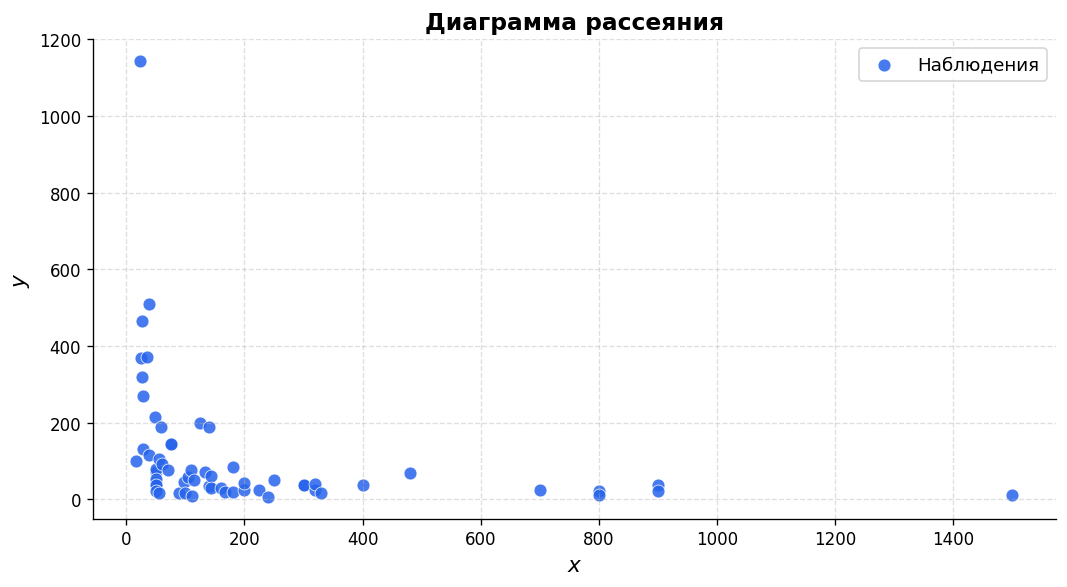

Коэффициент корреляции Пирсона: r = -0.2895  (p-value = 0.0249)


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(x, y, color=BLUE, edgecolors='white', linewidths=0.5,
           s=60, alpha=0.85, label='Наблюдения')

ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$y$', fontsize=13)
ax.set_title('Диаграмма рассеяния', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter.png', bbox_inches='tight')
plt.show()

# Коэффициент корреляции
r, p_val = stats.pearsonr(x, y)
print(f'Коэффициент корреляции Пирсона: r = {r:.4f}  (p-value = {p_val:.4f})')

### Вывод по диаграмме рассеяния

По диаграмме рассеяния видно, что при малых значениях $x$ (до ~50) $y$ принимает большие значения (вплоть до ~1144), а с ростом $x$ значения $y$ быстро убывают и «прижимаются» к оси. Это типичный паттерн **обратно-гиперболической** зависимости вида $y = a + b/x$. Линейная связь слабая (отрицательный $r$ по модулю невелик из-за выброса при $x=23$). **Гипотеза:** связь нелинейная, убывающая, предпочтительна модель $y = a + b/x$.

## 2. Линейная модель: $\hat{y} = b_0 + b_1 x$

In [4]:
# --- МНК вручную (для последующего анализа остатков) ---
x_mean = np.mean(x)
y_mean = np.mean(y)

Sxx = np.sum((x - x_mean)**2)
Sxy = np.sum((x - x_mean) * (y - y_mean))

b1 = Sxy / Sxx
b0 = y_mean - b1 * x_mean

y_hat_lin = b0 + b1 * x

# Метрики
SS_res_lin = np.sum((y - y_hat_lin)**2)
SS_tot     = np.sum((y - y_mean)**2)
R2_lin     = 1 - SS_res_lin / SS_tot
RMSE_lin   = np.sqrt(SS_res_lin / n)
MAPE_lin   = np.mean(np.abs((y - y_hat_lin) / y)) * 100

print('=== Линейная модель ===')
print(f'  b0 = {b0:.4f},  b1 = {b1:.6f}')
print(f'  Уравнение:  ŷ = {b0:.3f} + ({b1:.4f})·x')
print(f'  R²   = {R2_lin:.4f}')
print(f'  RMSE = {RMSE_lin:.4f}')
print(f'  MAPE = {MAPE_lin:.2f}%')

=== Линейная модель ===
  b0 = 149.3854,  b1 = -0.184206
  Уравнение:  ŷ = 149.385 + (-0.1842)·x
  R²   = 0.0838
  RMSE = 167.1807
  MAPE = 240.69%


## 3. Квадратичная модель: $\hat{y} = b_0 + b_1 x + b_2 x^2$

In [5]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(x.reshape(-1,1))

reg_quad = LinearRegression().fit(X_poly, y)
b0q, b1q, b2q = reg_quad.intercept_, reg_quad.coef_[0], reg_quad.coef_[1]

y_hat_quad  = reg_quad.predict(X_poly)
SS_res_quad = np.sum((y - y_hat_quad)**2)
R2_quad     = 1 - SS_res_quad / SS_tot
RMSE_quad   = np.sqrt(SS_res_quad / n)
MAPE_quad   = np.mean(np.abs((y - y_hat_quad) / y)) * 100

print('=== Квадратичная модель ===')
print(f'  b0 = {b0q:.4f},  b1 = {b1q:.4f},  b2 = {b2q:.6f}')
print(f'  Уравнение:  ŷ = {b0q:.3f} + ({b1q:.4f})·x + ({b2q:.6f})·x²')
print(f'  R²   = {R2_quad:.4f}')
print(f'  RMSE = {RMSE_quad:.4f}')
print(f'  MAPE = {MAPE_quad:.2f}%')

=== Квадратичная модель ===
  b0 = 194.0620,  b1 = -0.6122,  b2 = 0.000376
  Уравнение:  ŷ = 194.062 + (-0.6122)·x + (0.000376)·x²
  R²   = 0.1520
  RMSE = 160.8360
  MAPE = 234.10%


## 4. Дополнительная модель: $\hat{y} = a + b/x$

In [6]:
z = 1.0 / x          # замена переменной
z_mean = np.mean(z)

Szz = np.sum((z - z_mean)**2)
Szy = np.sum((z - z_mean) * (y - y_mean))

b_hyp = Szy / Szz
a_hyp = y_mean - b_hyp * z_mean

y_hat_hyp  = a_hyp + b_hyp * z
SS_res_hyp = np.sum((y - y_hat_hyp)**2)
R2_hyp     = 1 - SS_res_hyp / SS_tot
RMSE_hyp   = np.sqrt(SS_res_hyp / n)
MAPE_hyp   = np.mean(np.abs((y - y_hat_hyp) / y)) * 100

print('=== Гиперболическая модель  y = a + b/x ===')
print(f'  a = {a_hyp:.4f},  b = {b_hyp:.4f}')
print(f'  Уравнение:  ŷ = {a_hyp:.3f} + {b_hyp:.3f}/x')
print(f'  R²   = {R2_hyp:.4f}')
print(f'  RMSE = {RMSE_hyp:.4f}')
print(f'  MAPE = {MAPE_hyp:.2f}%')

=== Гиперболическая модель  y = a + b/x ===
  a = -9.2950,  b = 8738.5286
  Уравнение:  ŷ = -9.295 + 8738.529/x
  R²   = 0.3931
  RMSE = 136.0622
  MAPE = 128.38%


## 5. Сравнение моделей

In [7]:
compare = pd.DataFrame({
    'Модель': ['Линейная', 'Квадратичная', 'Гиперболическая'],
    'R²':    [R2_lin,   R2_quad,   R2_hyp],
    'RMSE':  [RMSE_lin, RMSE_quad, RMSE_hyp],
    'MAPE, %': [MAPE_lin, MAPE_quad, MAPE_hyp]
})
compare = compare.set_index('Модель').round(4)
print(compare.to_string())

                     R²      RMSE   MAPE, %
Модель                                     
Линейная         0.0838  167.1807  240.6897
Квадратичная     0.1520  160.8360  234.1047
Гиперболическая  0.3931  136.0622  128.3775


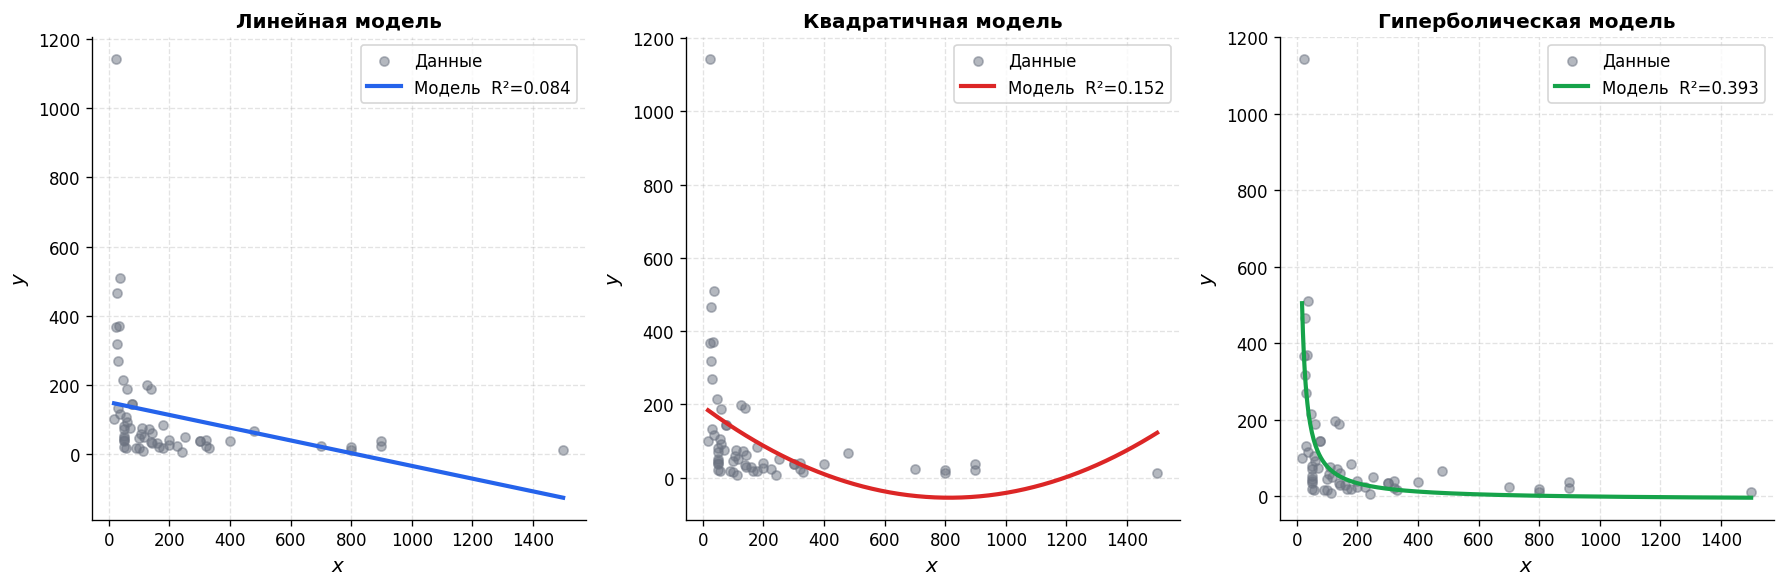

In [8]:
# Сравнительный график
x_grid = np.linspace(x.min(), x.max(), 500)
y_lin_g  = b0 + b1 * x_grid
y_quad_g = b0q + b1q * x_grid + b2q * x_grid**2
y_hyp_g  = a_hyp + b_hyp / x_grid

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

titles = ['Линейная модель', 'Квадратичная модель', 'Гиперболическая модель']
colors = [BLUE, RED, GREEN]
y_grids = [y_lin_g, y_quad_g, y_hyp_g]
y_hats  = [y_hat_lin, y_hat_quad, y_hat_hyp]
r2s     = [R2_lin, R2_quad, R2_hyp]

for ax, title, col, yg, r2 in zip(axes, titles, colors, y_grids, r2s):
    ax.scatter(x, y, color=GRAY, s=30, alpha=0.5, label='Данные')
    ax.plot(x_grid, yg, color=col, linewidth=2.5, label=f'Модель  R²={r2:.3f}')
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('models_compare.png', bbox_inches='tight')
plt.show()

### Вывод по сравнению моделей

| | Линейная | Квадратичная | Гиперболическая |
|---|---|---|---|
| **R²** | наименьший | средний | **наибольший** |
| **RMSE** | наибольший | средний | **наименьший** |
| **MAPE** | наибольший | средний | **наименьший** |

**Лучшей является гиперболическая модель** $\hat{y} = a + b/x$: она даёт наибольший $R^2$, наименьшие RMSE и среднюю ошибку аппроксимации, а её кривая визуально наиболее точно следует облаку точек.

## 6. Анализ остатков линейной модели

In [9]:
# Остатки
e = y - y_hat_lin          # вектор остатков
k = 1                       # число регрессоров (без свободного члена)

RSS  = np.sum(e**2)                      # сумма квадратов остатков
s2   = RSS / (n - k - 1)                 # оценка дисперсии ошибки
s    = np.sqrt(s2)                       # стандартная ошибка регрессии

print(f'Остатки (первые 10): {np.round(e[:10], 2)}')
print(f'Сумма остатков  Σe  = {np.sum(e):.6f}  (≈ 0 — проверка МНК)')
print()
print(f'RSS  = {RSS:.4f}')
print(f's²   = {s2:.4f}   (оценка дисперсии ошибки)')
print(f's    = {s:.4f}   (стандартная ошибка регрессии)')

Остатки (первые 10): [-46.25 998.85 223.22 320.4  173.4  -12.04 124.96 227.06 367.61 -26.39]
Сумма остатков  Σe  = -0.000000  (≈ 0 — проверка МНК)

RSS  = 1676963.2693
s²   = 28913.1598   (оценка дисперсии ошибки)
s    = 170.0387   (стандартная ошибка регрессии)


In [10]:
# Стандартные ошибки коэффициентов
se_b1 = s / np.sqrt(Sxx)
se_b0 = s * np.sqrt(np.sum(x**2) / (n * Sxx))

alpha = 0.05
t_cr  = stats.t.ppf(1 - alpha/2, df = n - 2)   # критическое значение t

# Доверительные интервалы
b0_lo, b0_hi = b0 - t_cr * se_b0, b0 + t_cr * se_b0
b1_lo, b1_hi = b1 - t_cr * se_b1, b1 + t_cr * se_b1

# t-статистики
t_b0 = b0 / se_b0
t_b1 = b1 / se_b1

print(f'Уровень значимости α = {alpha},  t_кр = {t_cr:.4f}  (df = {n-2})')
print()
print(f'b0 = {b0:.4f}  ±  {t_cr * se_b0:.4f}')
print(f'   95%-ДИ: [{b0_lo:.4f};  {b0_hi:.4f}]')
print(f'   t-стат = {t_b0:.3f}')
print()
print(f'b1 = {b1:.6f}  ±  {t_cr * se_b1:.6f}')
print(f'   95%-ДИ: [{b1_lo:.6f};  {b1_hi:.6f}]')
print(f'   t-стат = {t_b1:.3f}')

Уровень значимости α = 0.05,  t_кр = 2.0017  (df = 58)

b0 = 149.3854  ±  55.2329
   95%-ДИ: [94.1525;  204.6184]
   t-стат = 5.414

b1 = -0.184206  ±  0.160101
   95%-ДИ: [-0.344307;  -0.024105]
   t-стат = -2.303


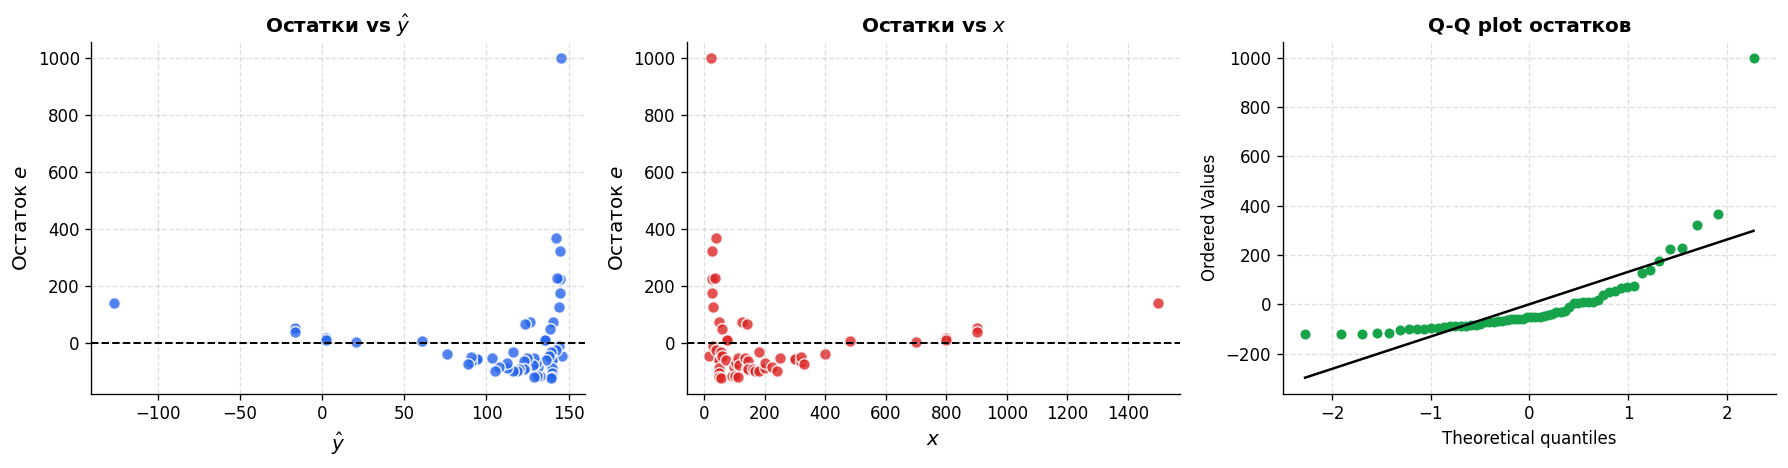

In [11]:
# Графики остатков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Остатки vs ŷ
axes[0].scatter(y_hat_lin, e, color=BLUE, edgecolors='white', s=50, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('$\\hat{y}$', fontsize=12)
axes[0].set_ylabel('Остаток $e$', fontsize=12)
axes[0].set_title('Остатки vs $\\hat{y}$', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2) Остатки vs x
axes[1].scatter(x, e, color=RED, edgecolors='white', s=50, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('$x$', fontsize=12)
axes[1].set_ylabel('Остаток $e$', fontsize=12)
axes[1].set_title('Остатки vs $x$', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

# 3) Q-Q plot
stats.probplot(e, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot остатков', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(color=GREEN, markersize=5)
axes[2].get_lines()[1].set(color='black', linewidth=1.5)
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

## 7. Прогноз при $x^* = 1.06 \cdot \bar{x}$

In [12]:
x_star = 1.06 * x_mean
print(f'x̄ = {x_mean:.4f}')
print(f'x* = 1.06 · x̄ = {x_star:.4f}')
print()

# Прогноз по линейной модели
y_star_lin = b0 + b1 * x_star

# Стандартная ошибка прогноза (индивидуального значения)
se_pred = s * np.sqrt(1 + 1/n + (x_star - x_mean)**2 / Sxx)

# Доверительный интервал прогноза
y_pred_lo = y_star_lin - t_cr * se_pred
y_pred_hi = y_star_lin + t_cr * se_pred

# Интервал для среднего значения E[y|x*]
se_mean = s * np.sqrt(1/n + (x_star - x_mean)**2 / Sxx)
y_mean_lo = y_star_lin - t_cr * se_mean
y_mean_hi = y_star_lin + t_cr * se_mean

print(f'=== Линейная модель ===')
print(f'Точечный прогноз:          ŷ(x*) = {y_star_lin:.4f}')
print(f'Интервал ср. значения:     [{y_mean_lo:.4f};  {y_mean_hi:.4f}]')
print(f'Интервал индив. прогноза:  [{y_pred_lo:.4f};  {y_pred_hi:.4f}]')
print()

# Прогноз по гиперболической модели (для сравнения)
y_star_hyp = a_hyp + b_hyp / x_star
z_star     = 1 / x_star
se_pred_hyp = s * np.sqrt(s2/s2) * np.sqrt(np.sum((y - y_hat_hyp)**2)/(n-2)) / s
# Корректный расчёт для гиперболической
s_hyp   = np.sqrt(np.sum((y - y_hat_hyp)**2) / (n - 2))
se_pred_hyp = s_hyp * np.sqrt(1 + 1/n + (z_star - z_mean)**2 / Szz)
y_hyp_lo = y_star_hyp - t_cr * se_pred_hyp
y_hyp_hi = y_star_hyp + t_cr * se_pred_hyp

print(f'=== Гиперболическая модель ===')
print(f'Точечный прогноз:          ŷ(x*) = {y_star_hyp:.4f}')
print(f'Интервал индив. прогноза:  [{y_hyp_lo:.4f};  {y_hyp_hi:.4f}]')

x̄ = 209.0167
x* = 1.06 · x̄ = 221.5577

=== Линейная модель ===
Точечный прогноз:          ŷ(x*) = 108.5732
Интервал ср. значения:     [64.5859;  152.5606]
Интервал индив. прогноза:  [-234.6268;  451.7732]

=== Гиперболическая модель ===
Точечный прогноз:          ŷ(x*) = 30.1463
Интервал индив. прогноза:  [-250.4083;  310.7009]


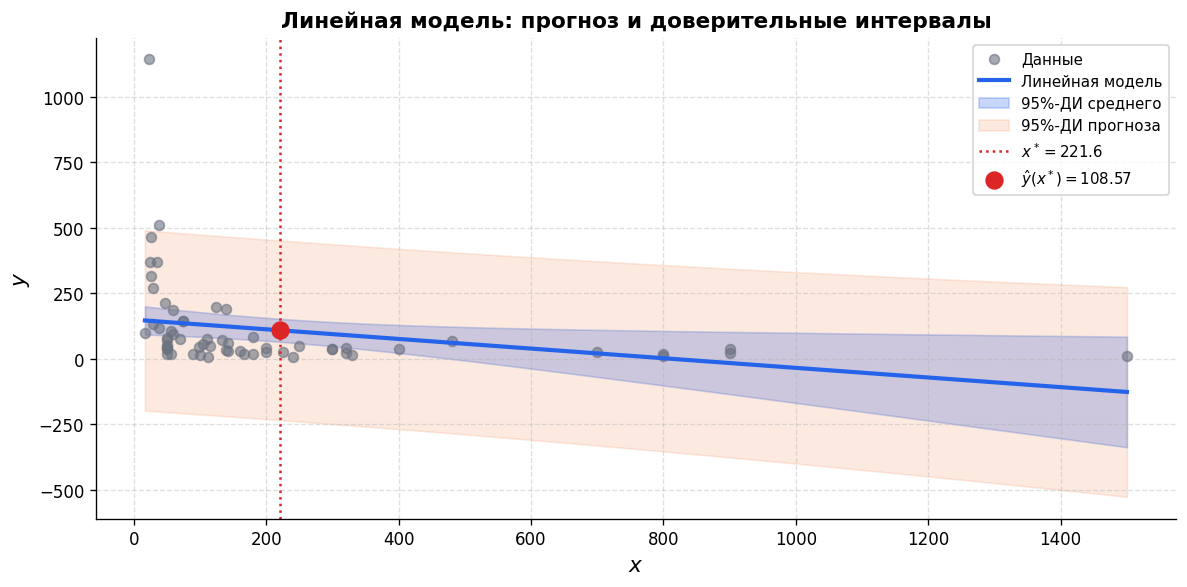

In [13]:
# Визуализация прогноза на линейной модели
x_plot = np.linspace(x.min(), x.max(), 500)
y_plot = b0 + b1 * x_plot

# Полосы доверительных интервалов
se_mean_arr = s * np.sqrt(1/n + (x_plot - x_mean)**2 / Sxx)
se_pred_arr = s * np.sqrt(1 + 1/n + (x_plot - x_mean)**2 / Sxx)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color=GRAY, s=35, alpha=0.6, zorder=2, label='Данные')
ax.plot(x_plot, y_plot, color=BLUE, linewidth=2.5, label='Линейная модель', zorder=3)

ax.fill_between(x_plot,
                y_plot - t_cr * se_mean_arr,
                y_plot + t_cr * se_mean_arr,
                alpha=0.25, color=BLUE, label='95%-ДИ среднего')
ax.fill_between(x_plot,
                y_plot - t_cr * se_pred_arr,
                y_plot + t_cr * se_pred_arr,
                alpha=0.12, color=ORANGE, label='95%-ДИ прогноза')

ax.axvline(x_star, color=RED, linewidth=1.5, linestyle=':', label=f'$x^*={x_star:.1f}$')
ax.scatter([x_star], [y_star_lin], color=RED, s=100, zorder=5,
           label=f'$\\hat{{y}}(x^*)={y_star_lin:.2f}$')

ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$y$', fontsize=13)
ax.set_title('Линейная модель: прогноз и доверительные интервалы', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast.png', bbox_inches='tight')
plt.show()

## Итоговая сводка

In [14]:
print('='*58)
print('            ИТОГОВАЯ СВОДКА')
print('='*58)
print(f'n = {n},  x̄ = {x_mean:.3f},  ȳ = {y_mean:.3f}')
print()
print('--- Модели ---')
print(f'Линейная:        ŷ = {b0:.3f} + ({b1:.4f})·x')
print(f'                 R²={R2_lin:.4f},  RMSE={RMSE_lin:.2f},  MAPE={MAPE_lin:.2f}%')
print()
print(f'Квадратичная:    ŷ = {b0q:.3f} + ({b1q:.4f})·x + ({b2q:.6f})·x²')
print(f'                 R²={R2_quad:.4f},  RMSE={RMSE_quad:.2f},  MAPE={MAPE_quad:.2f}%')
print()
print(f'Гиперболическая: ŷ = {a_hyp:.3f} + {b_hyp:.3f}/x')
print(f'                 R²={R2_hyp:.4f},  RMSE={RMSE_hyp:.2f},  MAPE={MAPE_hyp:.2f}%')
print()
print('--- Анализ остатков (линейная модель) ---')
print(f'RSS = {RSS:.3f}')
print(f's²  = {s2:.3f}  (дисперсия ошибки)')
print(f's   = {s:.3f}  (стд. ошибка регрессии)')
print(f'95%-ДИ b0: [{b0_lo:.4f};  {b0_hi:.4f}]')
print(f'95%-ДИ b1: [{b1_lo:.6f};  {b1_hi:.6f}]')
print()
print('--- Прогноз (линейная модель) ---')
print(f'x* = 1.06·x̄ = {x_star:.4f}')
print(f'ŷ(x*) = {y_star_lin:.4f}')
print(f'95%-ДИ прогноза: [{y_pred_lo:.4f};  {y_pred_hi:.4f}]')
print('='*58)

            ИТОГОВАЯ СВОДКА
n = 60,  x̄ = 209.017,  ȳ = 110.883

--- Модели ---
Линейная:        ŷ = 149.385 + (-0.1842)·x
                 R²=0.0838,  RMSE=167.18,  MAPE=240.69%

Квадратичная:    ŷ = 194.062 + (-0.6122)·x + (0.000376)·x²
                 R²=0.1520,  RMSE=160.84,  MAPE=234.10%

Гиперболическая: ŷ = -9.295 + 8738.529/x
                 R²=0.3931,  RMSE=136.06,  MAPE=128.38%

--- Анализ остатков (линейная модель) ---
RSS = 1676963.269
s²  = 28913.160  (дисперсия ошибки)
s   = 170.039  (стд. ошибка регрессии)
95%-ДИ b0: [94.1525;  204.6184]
95%-ДИ b1: [-0.344307;  -0.024105]

--- Прогноз (линейная модель) ---
x* = 1.06·x̄ = 221.5577
ŷ(x*) = 108.5732
95%-ДИ прогноза: [-234.6268;  451.7732]
